>>> [1/4] 正在生成物理场景与 GNN 拓扑...
>>> [1/3] 初始化协同定位物理场景...
>>> [2/3] 计算稠密全图基准 CRLB...
    原始稠密图边数: 121
    原始稠密图 CRLB: 148.7346

>>> [3/3] 开始 GNN 剪枝训练...
Epoch 000 | Total Loss: 7.2754 | CRLB: 20284.2539 (是基准的 136.38 倍) | 保留边数: 59/121 | Tau: 0.997
Epoch 020 | Total Loss: 6.7502 | CRLB: 23680.0449 (是基准的 159.21 倍) | 保留边数: 42/121 | Tau: 0.941
Epoch 040 | Total Loss: 3.2027 | CRLB: 331.9137 (是基准的 2.23 倍) | 保留边数: 60/121 | Tau: 0.889
Epoch 060 | Total Loss: 3.2813 | CRLB: 197.0606 (是基准的 1.32 倍) | 保留边数: 75/121 | Tau: 0.839
Epoch 080 | Total Loss: 3.2831 | CRLB: 261.2067 (是基准的 1.76 倍) | 保留边数: 68/121 | Tau: 0.792
Epoch 100 | Total Loss: 2.9646 | CRLB: 294.9293 (是基准的 1.98 倍) | 保留边数: 57/121 | Tau: 0.748
Epoch 120 | Total Loss: 3.2255 | CRLB: 227.6188 (是基准的 1.53 倍) | 保留边数: 70/121 | Tau: 0.706
Epoch 140 | Total Loss: 3.6302 | CRLB: 194.8820 (是基准的 1.31 倍) | 保留边数: 84/121 | Tau: 0.666
Epoch 160 | Total Loss: 2.8128 | CRLB: 274.5082 (是基准的 1.85 倍) | 保留边数: 55/121 | Tau: 0.629
Epoch 180 | Total Loss: 3.1996 |

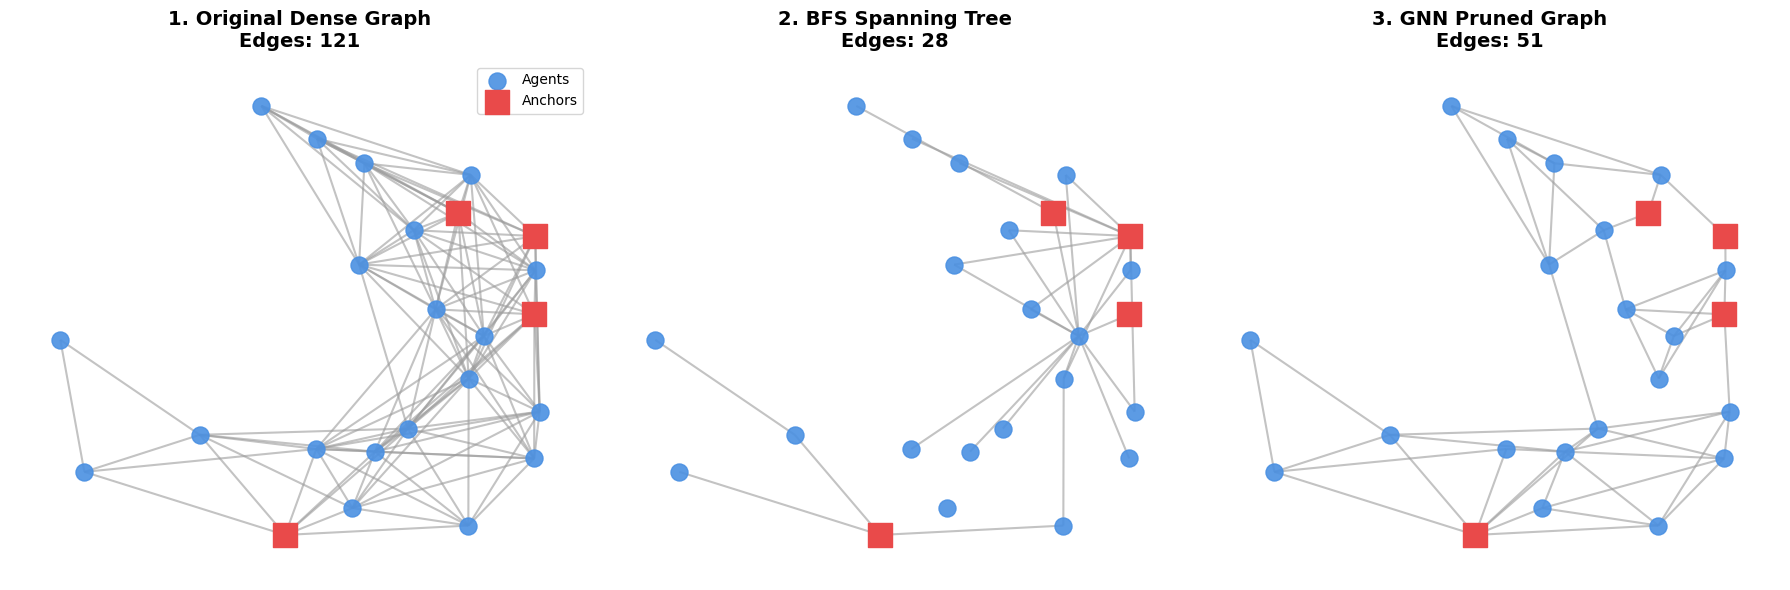

In [ ]:
import torch
import numpy as np

# 导入各个模块
from GNN_learning.train import train_gnn_sparsifier
from NBP_ST.BFS_tree import extract_bfs_tree_edges
from GNN_learning.bp import gaussian_bp_localization
from GNN_learning.visualize_topology import plot_topology_comparison

TORCH_SEED = 2          # 随机种子
LAMBDA_REG = 0.04       # 超参数 lambda
EPOCHS = 1000

def calculate_metrics(estimated_pos, true_pos, estimated_sigma):
    """评价指标：RMSE 和 误差校准度"""
    # 1. 真实绝对误差 (MSE 和 RMSE)
    errors = estimated_pos - true_pos
    mse_per_node = torch.sum(errors**2, dim=1) # 每个节点的欧式距离平方
    mean_mse = torch.mean(mse_per_node).item()
    rmse = np.sqrt(mean_mse)
    
    # 2. 算法自我评估的误差 (协方差矩阵的迹 Trace)
    # 迹越小，代表算法觉得自己越“准”
    trace_per_node = torch.diagonal(estimated_sigma, dim1=-2, dim2=-1).sum(dim=-1)
    mean_trace = torch.mean(trace_per_node).item()
    
    # 3. 过度自信倍率 (Overconfidence Ratio)
    # 理想状态下，实际误差 MSE 应该等于算法估计的 Trace (比值为 1.0)
    # 如果比值 >> 1.0，说明算法过度自信
    overconfidence_ratio = mean_mse / mean_trace
    
    return rmse, mean_trace, overconfidence_ratio

if __name__ == "__main__":
    torch.manual_seed(TORCH_SEED)
    
    # ==========================================
    # 1. 数据准备与图拓扑生成
    # ==========================================
    print(">>> [1/4] 正在生成物理场景与 GNN 拓扑...")
    model, gnn_weights, data, final_edges, crlb_final, crlb_baseline = train_gnn_sparsifier(
        epochs=EPOCHS, lr=0.01, lambda_reg=LAMBDA_REG
    )
    
    agents_pos_true = data['true_agents_pos']
    agents_pos_init = data['init_agents_pos']
    anchors_pos = data['anchors_pos']
    edge_index = data['edge_index']
    measurements = data['measurements']
    edge_variances = data['edge_variances']
    is_anchor_edge = data['is_anchor_edge']
    E_total = edge_index.shape[1]
    
    print(f"\n>>> [2/4] 正在提取 BFS 树...")
    bfs_weights = extract_bfs_tree_edges(agents_pos_true.shape[0], anchors_pos.shape[0], edge_index)
    
    dense_weights = torch.ones(E_total)
    
    # ==========================================
    # 2. 将三种拓扑输入高斯 BP 算法进行 25 轮迭代
    # ==========================================
    print("\n>>> [3/4] 正在运行 Gaussian BP 定位算法...")
    num_iters = 25
    
    # 测试 A：原图 (Dense)
    mu_dense, sigma_dense, iters_dense = gaussian_bp_localization(
        agents_pos_init, anchors_pos, edge_index, measurements, edge_variances, 
        is_anchor_edge, edge_weights=dense_weights, num_iters=num_iters
    )
    
    # 测试 B：BFS 树 (Tree)
    mu_bfs, sigma_bfs, iters_bfs = gaussian_bp_localization(
        agents_pos_init, anchors_pos, edge_index, measurements, edge_variances, 
        is_anchor_edge, edge_weights=bfs_weights, num_iters=num_iters
    )
    
    # 测试 C：GNN 稀疏图 (Sparse)
    mu_gnn, sigma_gnn, iters_gnn = gaussian_bp_localization(
        agents_pos_init, anchors_pos, edge_index, measurements, edge_variances, 
        is_anchor_edge, edge_weights=gnn_weights, num_iters=num_iters
    )
    
    # ==========================================
    # 3. 结果核算与打印
    # ==========================================
    print("\n>>> [4/4] 结果核算中...")
    print("=" * 90)
    print(f"{'测试模型':<10} | {'保留边数':<8} | {'收敛迭代':<4} | {'定位 RMSE':<8} | {'过度自信倍率':<15}")
    print("-" * 90)
    
    # Dense
    rmse_dense, trace_dense, oc_dense = calculate_metrics(mu_dense, agents_pos_true, sigma_dense)
    print(f"{'1. 原图 (Dense)':<14} | {E_total:<8} | {iters_dense:<8} | {rmse_dense:<10.4f} | {oc_dense:<15.2f}")
    
    # BFS
    rmse_bfs, trace_bfs, oc_bfs = calculate_metrics(mu_bfs, agents_pos_true, sigma_bfs)
    edges_bfs = int(torch.sum(bfs_weights).item())
    print(f"{'2. 传统树 (BFS)':<13} | {edges_bfs:<8} | {iters_bfs:<8} | {rmse_bfs:<10.4f} | {oc_bfs:<15.2f}")
    
    # GNN
    rmse_gnn, trace_gnn, oc_gnn = calculate_metrics(mu_gnn, agents_pos_true, sigma_gnn)
    edges_gnn = int(torch.sum(gnn_weights).item())
    print(f"{'3. 智能图 (GNN)':<13} | {edges_gnn:<8} | {iters_gnn:<8} | {rmse_gnn:<10.4f} | {oc_gnn:<15.2f}")
    print("=" * 90)

    plot_topology_comparison(data, gnn_weights, bfs_weights) # 拓扑对比图